<a href="https://colab.research.google.com/github/pinakm9/fp-solvers/blob/master/colab-solvers/L63_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# run this cell to download data and necessary modules
import os, shutil
repo = 'fp-solvers'
if os.path.isdir(repo):
  shutil.rmtree(repo)
!git clone https://github.com/pinakm9/fp-solvers.git
# add modules folder to Python's search path
import os, sys
from pathlib import Path
script_dir = Path(os.path.dirname(os.path.abspath('')))
module_dir = str(script_dir)
sys.path.insert(0, repo + '/modules')
print(module_dir)

# import the rest of the modules
%matplotlib nbagg
%matplotlib inline
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt
import arch
import pandas as pd
import tensorflow_probability as tfp
import time  
import sim
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
tfd = tfp.distributions

Cloning into 'fp-solvers'...
remote: Enumerating objects: 14936, done.
remote: Counting objects: 100% (306/306), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 14936 (delta 141), reused 288 (delta 129), pack-reused 14630
Receiving objects: 100% (14936/14936), 804.90 MiB | 42.61 MiB/s, done.
Resolving deltas: 100% (7296/7296), done.
Updating files: 100% (14673/14673), done.
/


**Set computation and plotting parameters**

In [27]:
# set up computation parameters
dim = 3
n_particles = int(1e7)
n_subdivs = 100
save_folder = '{}/non-grad3D/data/L63'.format(repo)
n_steps = 3
n_repeats = 200
dt = 0.01
alpha, beta, rho = 10., 8./3., 28.
t = dt * n_steps
max_comp = int(1e6)
quad_method = 'Gauss_Legendre'
n_int_subdivs = 100
degree = 4
DTYPE = 'float32'

# set up plotting parameters
scale = 15
xlabel_size = ylabel_size = 15 + scale
tick_size = 10 + scale
legend_size = 15 + scale
title_size = 15 + scale
cbar_tick_size = 10 + scale

**Define the problem: $\mu, \sigma, p_0$**

In [28]:
def mu(X):
    x, y, z = tf.split(X, [1, 1, 1], axis=-1)
    p = alpha * (y - x)
    q = x * (rho - z) - y 
    r = x * y - beta * z 
    return tf.concat([p, q, r], axis=-1)

def mu_np(X):
    x, y, z = np.split(X, dim, axis=-1)
    p = alpha * (y - x) 
    q = x * (rho - z) - y 
    r = x * y - beta * z
    return np.concatenate([p, q, r], axis=-1)

sigma = 10.
D = sigma**2 / 2.

l = np.ones(dim, dtype=DTYPE)
g1 = tfd.MultivariateNormalDiag(loc=2.*l, scale_diag=l)
g2 = tfd.MultivariateNormalDiag(loc=-2.*l, scale_diag=l)
mix = 0.5
rv0 = tfd.Mixture(cat=tfd.Categorical(probs=[mix, 1.-mix]), components=[g1, g2])
log_p0 = lambda x: tf.reshape(rv0.log_prob(x), (-1, 1))

**Set up Monte-Carlo solver**

In [29]:
X0 = rv0.sample(n_particles).numpy()
mc_prob = sim.MCProb(save_folder, n_subdivs, mu_np, sigma, X0)
mc_prob.ready(n_steps=n_steps, dt=dt, lims=None)

Time taken by propagate is 34.23305654525757 seconds
Time taken by set_grid is 29.65353798866272 seconds
Time taken by assign_pts is 37.28450345993042 seconds
Time taken by ready is 101.17144131660461 seconds


**Load the neural network**

In [30]:
n_theta = arch.LSTMForgetNet(50, 3, tf.float32, name="L63")
n_theta.load_weights('{}/non-grad3D/data/L63/1M/{}'.format(repo, n_theta.name)).expect_partial()
X = tf.random.uniform(shape=(10, dim))
n_theta(*tf.split(X, dim, axis=-1))

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[2.5339966],
       [2.74217  ],
       [2.441343 ],
       [2.4221196],
       [2.5876884],
       [2.571423 ],
       [2.4075654],
       [2.4380922],
       [2.336833 ],
       [2.5215359]], dtype=float32)>

**Compute, plot and save**

Streaming output truncated to the last 5000 lines.
grid_index = (19, 58), time taken = 38.9606
grid_index = (19, 59), time taken = 39.0667
grid_index = (19, 60), time taken = 39.1691
grid_index = (19, 61), time taken = 39.2741
grid_index = (19, 62), time taken = 39.3781
grid_index = (19, 63), time taken = 39.4833
grid_index = (19, 64), time taken = 39.5880
grid_index = (19, 65), time taken = 39.6928
grid_index = (19, 66), time taken = 39.7971
grid_index = (19, 67), time taken = 39.9014
grid_index = (19, 68), time taken = 40.0055
grid_index = (19, 73), time taken = 40.1093
grid_index = (20, 20), time taken = 40.2129
grid_index = (20, 23), time taken = 40.3172
grid_index = (20, 24), time taken = 40.4204
grid_index = (20, 25), time taken = 40.5240
grid_index = (20, 26), time taken = 40.6265
grid_index = (20, 27), time taken = 40.7309
grid_index = (20, 28), time taken = 40.8345
grid_index = (20, 29), time taken = 40.9388
grid_index = (20, 30), time taken = 41.0424
grid_index = (20, 31), ti

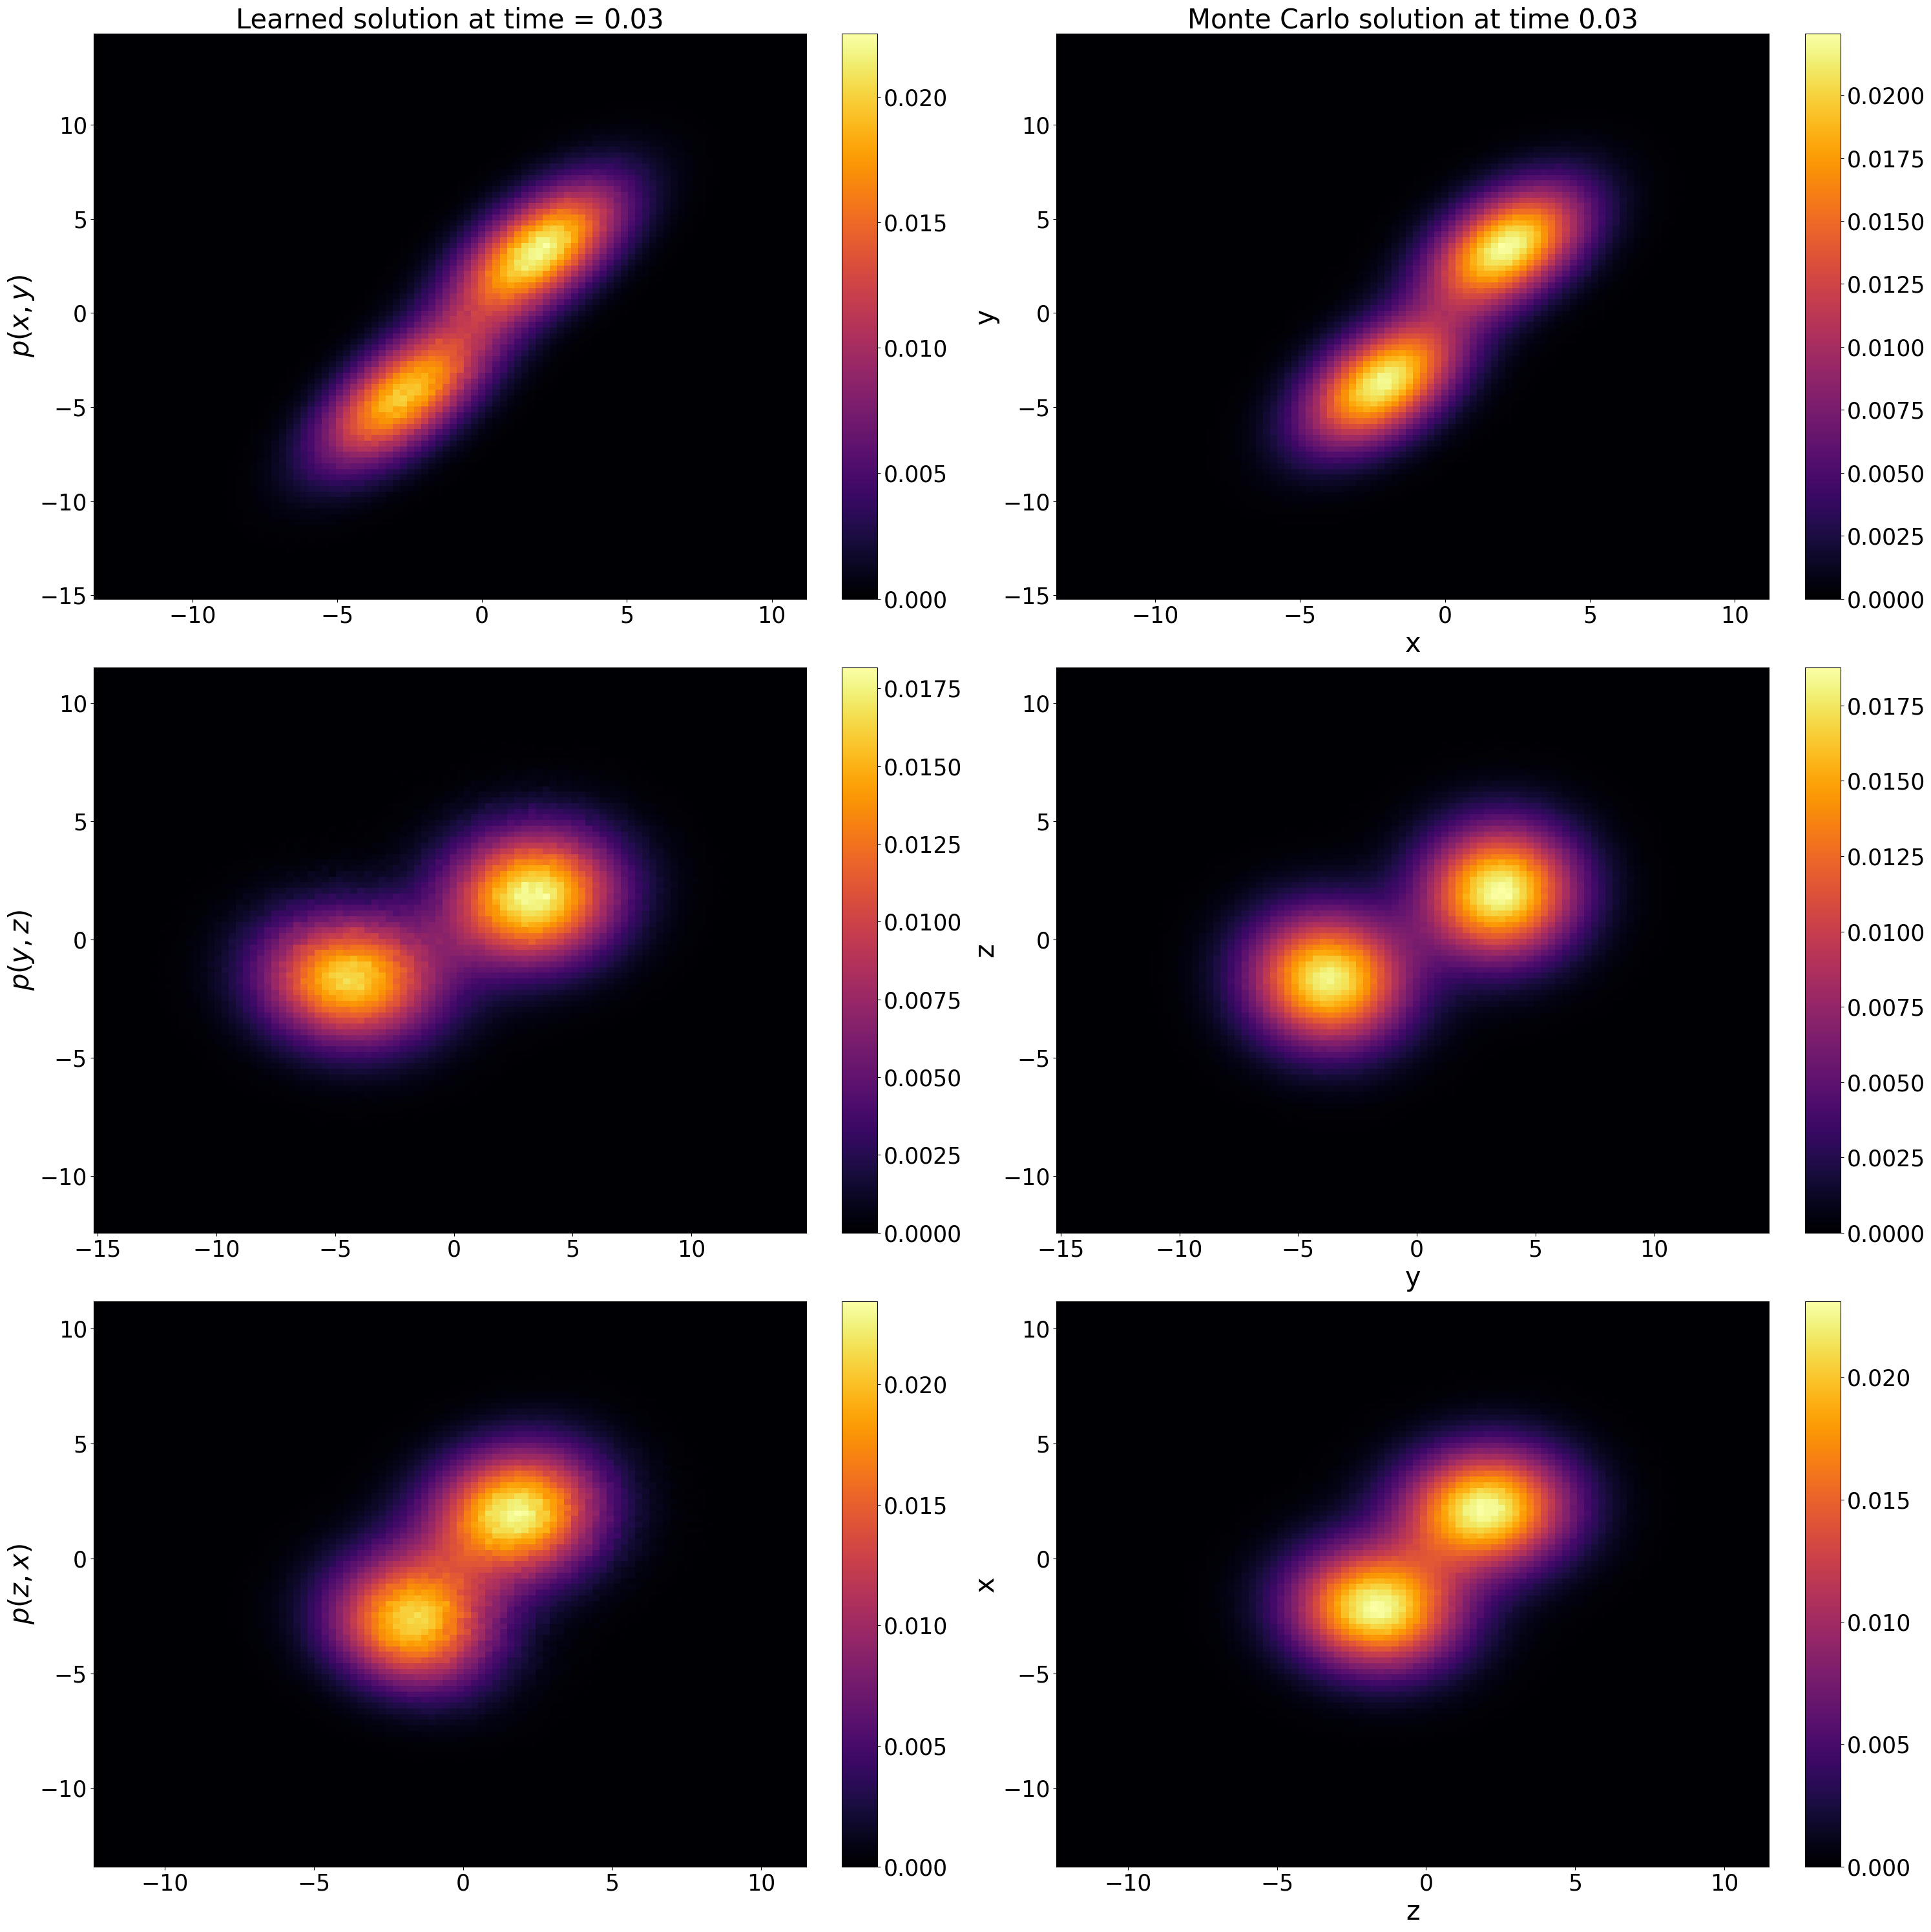

In [31]:
grid = mc_prob.get_grid()
low = grid.mins
high = grid.maxs
filter = mc_prob.save_folder + '/ensemble.csv'
prune = False

# define 6 subplots
fig_all = plt.figure(figsize=(30, 30))
ax_1l = fig_all.add_subplot(321) 
ax_1m = fig_all.add_subplot(322)
ax_2l = fig_all.add_subplot(323) 
ax_2m = fig_all.add_subplot(324)
ax_3l = fig_all.add_subplot(325) 
ax_3m = fig_all.add_subplot(326)

# position colorbars
div_1 = make_axes_locatable(ax_1l)
cax_1 = div_1.append_axes('right', '5%', '5%')
div_2 = make_axes_locatable(ax_2l)
cax_2 = div_2.append_axes('right', '5%', '5%')
div_3 = make_axes_locatable(ax_3l)
cax_3 = div_3.append_axes('right', '5%', '5%')
div_4 = make_axes_locatable(ax_1m)
cax_4 = div_4.append_axes('right', '5%', '5%')
div_5 = make_axes_locatable(ax_2m)
cax_5 = div_5.append_axes('right', '5%', '5%')
div_6 = make_axes_locatable(ax_3m)
cax_6 = div_6.append_axes('right', '5%', '5%')

# set label size
ax_1l.tick_params(axis='both', which='major', labelsize=tick_size)
ax_1l.tick_params(axis='both', which='minor', labelsize=tick_size)
ax_2l.tick_params(axis='both', which='major', labelsize=tick_size)
ax_2l.tick_params(axis='both', which='minor', labelsize=tick_size)
ax_3l.tick_params(axis='both', which='major', labelsize=tick_size)
ax_3l.tick_params(axis='both', which='minor', labelsize=tick_size)
ax_1m.tick_params(axis='both', which='major', labelsize=tick_size)
ax_1m.tick_params(axis='both', which='minor', labelsize=tick_size)
ax_2m.tick_params(axis='both', which='major', labelsize=tick_size)
ax_2m.tick_params(axis='both', which='minor', labelsize=tick_size)
ax_3m.tick_params(axis='both', which='major', labelsize=tick_size)
ax_3m.tick_params(axis='both', which='minor', labelsize=tick_size)

# write titles and labels
ax_1l.set_title('Learned solution at time = {:.2f}'.format(t), fontsize=title_size)
ax_1l.set_ylabel(r'$p(x, y)$', fontsize=ylabel_size)
ax_2l.set_ylabel(r'$p(y, z)$', fontsize=ylabel_size)
ax_3l.set_ylabel(r'$p(z, x)$', fontsize=ylabel_size)
ax_1m.set_title('Monte Carlo solution at time {:.2f}'.format(t), fontsize=title_size)
ax_1m.set_xlabel('x', fontsize=xlabel_size)
ax_1m.set_ylabel('y', fontsize=ylabel_size)
ax_2m.set_xlabel('y', fontsize=xlabel_size)
ax_2m.set_ylabel('z', fontsize=ylabel_size)
ax_3m.set_xlabel('z', fontsize=xlabel_size)
ax_3m.set_ylabel('x', fontsize=ylabel_size)



# compute, plot and save Monte-Carlo data
x = np.linspace(low[0], high[0], num=n_subdivs+1)[:-1].astype(DTYPE) + grid.h[0]/2. 
y = np.linspace(low[1], high[1], num=n_subdivs+1)[:-1].astype(DTYPE) + grid.h[1]/2.
z = np.linspace(low[2], high[2], num=n_subdivs+1)[:-1].astype(DTYPE) + grid.h[2]/2.
np.save('{}/x_t.npy'.format(save_folder), x)
np.save('{}/y_t.npy'.format(save_folder), y)
np.save('{}/z_t.npy'.format(save_folder), z)


p_1m = mc_prob.compute_p2(0, 1, save=False)
p_1m  /= (p_1m.sum() * grid.h[0] * grid.h[1])
np.save('{}/p_1m_t.npy'.format(save_folder), p_1m)
im = ax_1m.pcolormesh(x, y, p_1m.T, cmap='inferno', shading='auto')
cbar_1m = fig_all.colorbar(im, cax=cax_4, ax=ax_1m)
cbar_1m.ax.tick_params(labelsize=cbar_tick_size)
ax_1m.set_aspect("auto")


p_2m = mc_prob.compute_p2(1, 2, save=False)
p_2m  /= (p_2m.sum() * grid.h[1] * grid.h[2])
np.save('{}/p_2m_t.npy'.format(save_folder), p_2m)
im = ax_2m.pcolormesh(y, z, p_2m.T, cmap='inferno', shading='auto')
cbar_2m = fig_all.colorbar(im, cax=cax_5, ax=ax_2m)
cbar_2m.ax.tick_params(labelsize=cbar_tick_size)
ax_2m.set_aspect("auto")


p_3m = mc_prob.compute_p2(2, 0, save=False)
p_3m  /= (p_3m.sum() * grid.h[2] * grid.h[0])
np.save('{}/p_3m_t.npy'.format(save_folder), p_3m)
im = ax_3m.pcolormesh(z, x, p_3m.T, cmap='inferno', shading='auto')
cbar_3m = fig_all.colorbar(im, cax=cax_6, ax=ax_3m)
cbar_3m.ax.tick_params(labelsize=cbar_tick_size)
ax_3m.set_aspect("auto")


# set up Feynman-Kac procedure
fk = sim.FK32(save_folder=save_folder, n_subdivs=n_subdivs, n_int_subdivs=n_int_subdivs, mu=mu, sigma=sigma,\
               n_theta=n_theta, grid=grid, log_p0=log_p0, max_comp=max_comp)


# compute and save Feynman-Lac solution
nonzero_idx = list(zip(*np.where(p_1m > 0.)))
p_1l = fk.calc_2D_prob(n_steps, dt, n_repeats, 0, 1, filter=nonzero_idx, method=quad_method, prune=prune, num=n_int_subdivs, d=degree)
p_1l /= (p_1l.sum() * grid.h[0] * grid.h[1])
np.save('{}/p_1l_t.npy'.format(save_folder), p_1l)
# p_1l = np.load('{}/p_1l.npy'.format(save_folder))
im = ax_1l.pcolormesh(x, y, p_1l.T, cmap='inferno', shading='auto')
cbar_1l = fig_all.colorbar(im, cax=cax_1, ax=ax_1l)
cbar_1l.ax.tick_params(labelsize=cbar_tick_size)
ax_1l.set_aspect("auto")


nonzero_idx = list(zip(*np.where(p_2m > 0.)))
p_2l = fk.calc_2D_prob(n_steps, dt, n_repeats, 1, 2, filter=nonzero_idx, method=quad_method, prune=prune, num=n_int_subdivs, d=degree)
p_2l /= (p_2l.sum() *  grid.h[1] * grid.h[2])
np.save('{}/p_2l_t.npy'.format(save_folder), p_2l)
im = ax_2l.pcolormesh(y, z, p_2l.T, cmap='inferno')
cbar_2l = fig_all.colorbar(im, cax=cax_2, ax=ax_2l)
cbar_2l.ax.tick_params(labelsize=cbar_tick_size)
ax_2l.set_aspect("auto")


nonzero_idx = list(zip(*np.where(p_3m > 0.)))
p_3l = fk.calc_2D_prob(n_steps, dt, n_repeats, 2, 0, filter=nonzero_idx, method=quad_method, prune=prune, num=n_int_subdivs, d=degree)
p_3l /= (p_3l.sum() *  grid.h[2] * grid.h[0])
np.save('{}/p_3l_t.npy'.format(save_folder), p_3l)
im = ax_3l.pcolormesh(z, x, p_3l.T, cmap='inferno')
cbar_3l = fig_all.colorbar(im, cax=cax_3, ax=ax_3l)
cbar_3l.ax.tick_params(labelsize=cbar_tick_size)
ax_3l.set_aspect("auto")

# plot and save
fig_all.subplots_adjust(wspace=0.4, hspace=0.2)
plt.tight_layout()
plt.savefig('{}/plots/L63-time.png'.format(repo))

**Plot and save $p_0$**

In [ ]:
scale = 4
xlabel_size = ylabel_size = 15 + scale
tick_size = 10 + scale
legend_size = 15 + scale
title_size = 15 + scale
cbar_tick_size = 10 + scale

# define 6 subplots
fig_p0 = plt.figure(figsize=(8, 8))
ax = fig_p0.add_subplot(111) 


# position colorbars
div = make_axes_locatable(ax)
cax= div.append_axes('right', '5%', '5%')


# set label size
ax.tick_params(axis='both', which='major', labelsize=tick_size)
ax.tick_params(axis='both', which='minor', labelsize=tick_size)


# write titles and labels
ax.set_title(r'$p_0(a, b)$', fontsize=title_size)
ax.set_xlabel('a', fontsize=xlabel_size)
ax.set_ylabel('b', fontsize=ylabel_size)



# compute, plot and save p0 data
mc0 = sim.MCProb(save_folder, n_subdivs, mu_np, sigma, X0 = rv0.sample(int(1e7)).numpy())
mc0.ready(n_steps=0, dt=dt, lims=None)
grid = mc0.get_grid()
low = grid.mins
high = grid.maxs
x = np.linspace(low[0], high[0], num=n_subdivs+1)[:-1].astype(DTYPE) + grid.h[0]/2.
y = np.linspace(low[1], high[1], num=n_subdivs+1)[:-1].astype(DTYPE) + grid.h[1]/2.
np.save('{}/x_0.npy'.format(save_folder), x)
np.save('{}/y_0.npy'.format(save_folder), y)
p_0 = mc0.compute_p2(0, 1, save=False)
np.save('{}/p_0.npy'.format(save_folder), p_0)
im = ax.pcolormesh(x, y, p_0.T, cmap='inferno', shading='auto')
cbar = fig_p0.colorbar(im, cax=cax, ax=ax)
cbar.ax.tick_params(labelsize=cbar_tick_size)
ax.set_aspect("auto")
plt.tight_layout()
plt.savefig('{}/plots/L63-0.png'.format(repo))

Time taken by propagate is 30.754570484161377 seconds
Time taken by set_grid is 29.67923593521118 seconds
